## Assign spots to masks and quantify transcriptional activity

In [1]:
from ioMicro import *

#### Plot brightness distribution for each color channel

In [2]:
# Create dictionary of brightness values for each color channel from dataset
brightness_750 = {}
brightness_Cy5 = {}
brightness_Cy3 = {}

for fov in tqdm(range(184)):
    for hybe in range(1,8):
        for icol in range(3):
            spots = np.load(f'Z:\\Zane_20CRE\\9_14_2024__T7_20CRE\\analysis\\Conv_zscan__{fov:03d}--D{hybe:01d}_fits_icol{icol:01d}.npz')['Xh']
            h = spots[:,-1].tolist()
            if icol == 0:
                brightness_750[f'{fov:03d}-H{hybe}-{icol}'] = h
            
            if icol == 1:
                brightness_Cy5[f'{fov:03d}-H{hybe}-{icol}'] = h
                
            if icol == 2:
                brightness_Cy3[f'{fov:03d}-H{hybe}-{icol}'] = h

100%|████████████████████████████████████████████████████████████████████████████████| 184/184 [07:37<00:00,  2.49s/it]


In [3]:
from itertools import chain

# Combine brightness values across FOVs and rounds of imaging
h_750 = [brightness_750[i] for i in brightness_750]
h_750_total = list(chain.from_iterable(h_750))

h_Cy5 = [brightness_Cy5[i] for i in brightness_Cy5]
h_Cy5_total = list(chain.from_iterable(h_Cy5))

h_Cy3 = [brightness_Cy3[i] for i in brightness_Cy3]
h_Cy3_total = list(chain.from_iterable(h_Cy3))

Text(0.5, 0, 'Brightness')

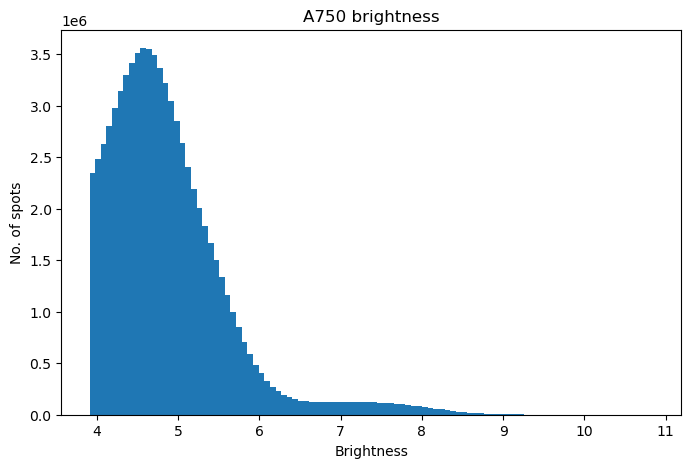

In [29]:
# Plot distribution of all brightness values for each color channel
fig, ax = plt.subplots(figsize=(8,5))

ax.hist(np.log(h_Cy3_total), bins=100)
ax.set_title('A750 brightness')
ax.set_ylabel('No. of spots')
ax.set_xlabel('Brightness')

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\Spot_thresholding\240925_T7_Cy3_total_brightness.pdf')

In [26]:
np.exp(6)

403.4287934927351

#### Fine tune brightness thresholds using raw image data

Text(0.5, 1.0, 'h>700 & h<5000')

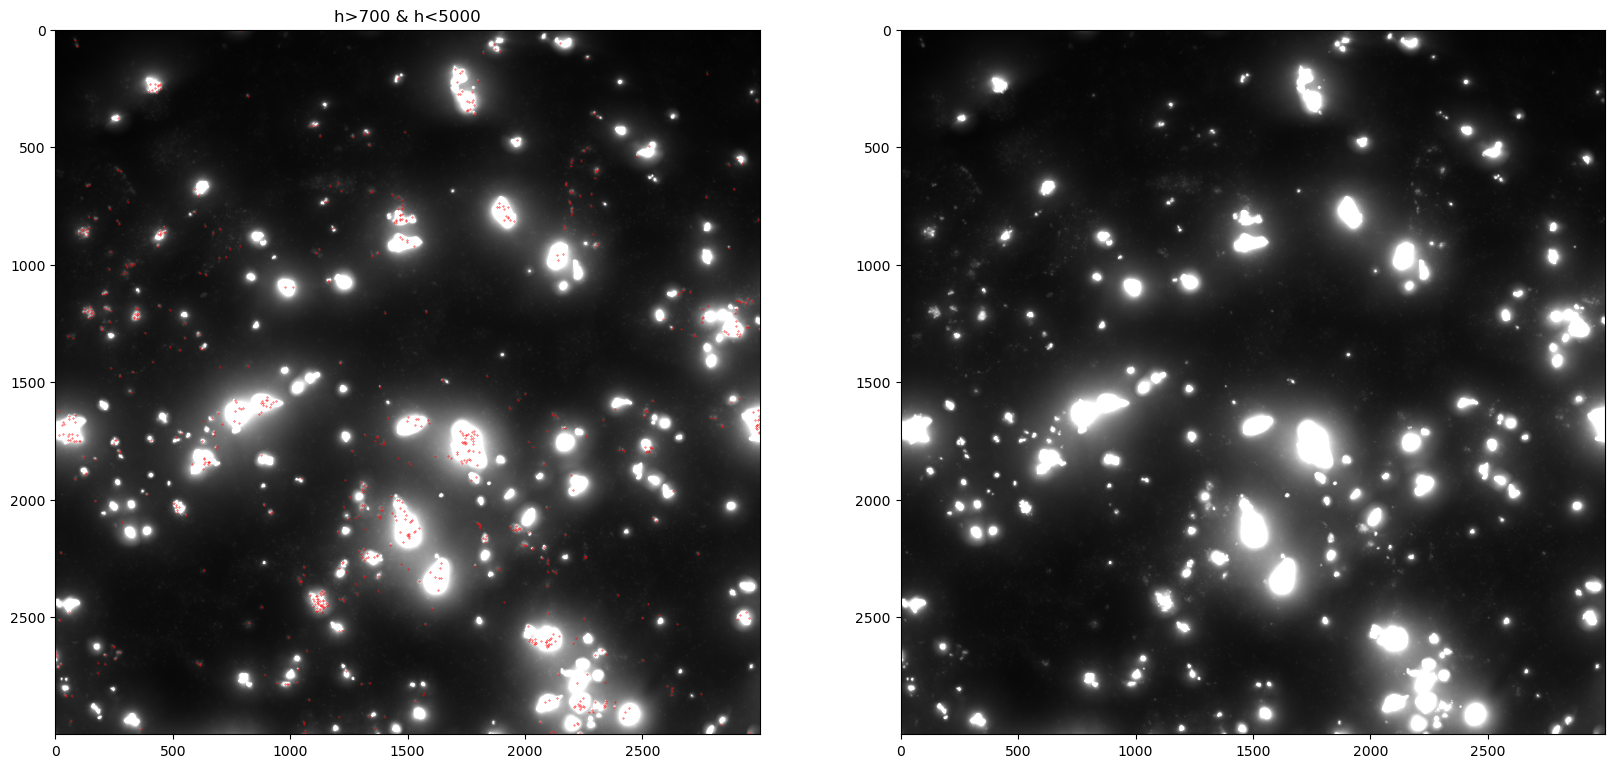

In [71]:
import matplotlib.pyplot as plt

CRE = np.load(r'Z:\Zane_20CRE\9_14_2024__T7_20CRE\analysis\Conv_zscan__042--D1_fits_icol0.npz')['Xh']
h = CRE[:,7]
keep = np.where((h>400) & (h<3000))
CRE_ = CRE[keep]

img = read_im(r'Z:\Zane_20CRE\9_14_2024__T7_20CRE\D1\Conv_zscan__042.zarr')

fig, axs = plt.subplots(1, 2, figsize=(20,20))

axs[0].imshow(np.max(img[0,:,:], axis=0), vmax=5000, cmap='gray')
axs[0].scatter(CRE_[:,2], CRE_[:,1], s=0.1, c='r', marker='o')

axs[1].imshow(np.max(img[0,:,:], axis=0), vmax=5000, cmap='gray')
axs[0].set_title('h>700 & h<5000')
# plt.gca().invert_yaxis()

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\Spot_thresholding\240819_CRE020_fov100.pdf')

#### Create dict for enhancer transcripts across all hybes and FOVs using universal brightness thresholds

In [8]:
np.arange(1,8)

array([1, 2, 3, 4, 5, 6, 7])

In [2]:
# Make a yuge dict for all CRE spots across FOVs.
# 
# Can use universal brightness thresholds for each laser channel, which are
# determined using the spot brightness distribution across all hybes.

CRE_counts = {}

for fov in tqdm(range(184)):
    for hybe in range(1,8):
        for icol in range(3):
            spots = np.load(f'Z:\\Zane_20CRE\\9_14_2024__T7_20CRE\\analysis\\Conv_zscan__{fov:03d}--D{hybe:01d}_fits_icol{icol:01d}.npz')['Xh']
            # correct the drift for spots as they're loaded in
            drifts = np.load(f'Z:\\Zane_20CRE\\9_14_2024__T7_20CRE\\drifts_polyA\\Conv_zscan__{fov:03d}_drift.pkl', allow_pickle=True)
            drift = drifts[f'D{hybe:01d}'][0]
            spots[:,:3]-=drift
            h = spots[:,-1]
            if icol == 0:
                keep = np.where((h>400) & (h<3000))
                spots_ = spots[keep]
                CRE_counts[f'{fov:03d}-D{hybe}-{icol}'] = spots_
            
            if icol == 1:
                keep = np.where((h>400) & (h<3000))
                spots_ = spots[keep]
                CRE_counts[f'{fov:03d}-D{hybe}-{icol}'] = spots_
                
            if icol == 2:
                keep = np.where((h>400) & (h<3000))
                spots_ = spots[keep]
                CRE_counts[f'{fov:03d}-D{hybe}-{icol}'] = spots_


100%|████████████████████████████████████████████████████████████████████████████████| 184/184 [03:06<00:00,  1.01s/it]


#### Convert keys from CRE_counts into the actual CRE names

In [3]:
# make list of CRE names and filter the converted dict keys into a new dict, fov_counts

CREs = ('CRE001', 'CRE002', 'CRE003', 'CRE004', 'CRE005', 'CRE006', 'CRE007', 'CRE008',
        'CRE009', 'CRE010', 'CRE011', 'CRE012', 'CRE013', 'CRE014', 'CRE015', 'CRE016',
        'CRE017', 'CRE018', 'CRE019', 'CRE020')

fov_filter = [f'{fov:03d}-D1-0', f'{fov:03d}-D1-1', f'{fov:03d}-D1-2', f'{fov:03d}-D2-0', f'{fov:03d}-D2-1', f'{fov:03d}-D2-2', f'{fov:03d}-D3-0', f'{fov:03d}-D3-1', f'{fov:03d}-D3-2', f'{fov:03d}-D4-0',
              f'{fov:03d}-D4-1', f'{fov:03d}-D4-2', f'{fov:03d}-D5-0', f'{fov:03d}-D5-1', f'{fov:03d}-D5-2', f'{fov:03d}-D6-0', f'{fov:03d}-D6-1', f'{fov:03d}-D6-2', f'{fov:03d}-D7-0', f'{fov:03d}-D7-1']

filterByKey = lambda keys: {ccre_conversion[x[3:]] : CRE_counts[x] for x in keys}

ccre_conversion = {channel_id[3:] : ccre for channel_id, ccre in zip(fov_filter, CREs)}

fov_counts = []

for fov in tqdm(range(184)):
    fov_counts.append(filterByKey(fov_filter))

100%|████████████████████████████████████████████████████████████████████████████| 184/184 [00:00<00:00, 184232.98it/s]


#### Create a cell by gene matrix for all enhancer spots using the appropriate segmentation masks

In [4]:
# Assign spots for each CRE to masks generated from Cellpose and combine into a pandas dataframe

import pandas as pd
import numpy as np

masked_spots = []
all_cbg = []
fov_means = []

for fov in tqdm(range(184)):
    # load cellpose masks and add (FOV x 1000) to the mask values to distinguish them from other FOVs
    seg_mask = np.load(f'C:\\Users\\zgibbs\\cellpose\\20CRE_T7_Sept_2024\\polyA\\Conv_zscan__{fov:03d}_seg.npy', allow_pickle=True)[()]
    mask_id = fov * 1000 
    seg_mask['masks'] = seg_mask['masks'] + mask_id 

    # specify the appropriate FOV for spots
    spots = fov_counts[fov]
    # filter spots to remove those outside the image dimensions following drift correction
    filtered_spots = {key: coords[(coords[:, 2] <= 2999) & (coords[:, 2] > 0) & (coords[:, 1] <= 2999) & (coords[:, 1] > 0), :] for key, coords in spots.items()}
    
    # round the x,y coordinates for decoded spots and assign to the masks from cellpose
    spot_masks = []
    for key in filtered_spots.keys():
        filtered_spots[key][:,2] = np.around(filtered_spots[key][:,2])
        filtered_spots[key][:,1] = np.around(filtered_spots[key][:,1])
        masks = seg_mask['masks'][np.around(filtered_spots[key][:,1]).astype(int), np.around(filtered_spots[key][:,2]).astype(int)]
        spot_masks += [np.array([masks, np.array([key] * (filtered_spots[key].shape[0])), np.around(filtered_spots[key][:,2]), np.around(filtered_spots[key][:,1])])]
        
    spot_masks = np.hstack(spot_masks).T
    barcodes = pd.DataFrame(data=spot_masks, columns=['masks', 'cre_id', 'x_round', 'y_round'])
    cell_by_gene = pd.crosstab(barcodes.masks, barcodes.cre_id)
    fov_means.append(cell_by_gene.mean(axis=0))
    all_cbg.append(cell_by_gene)
    
    # can save the cell-by-gene matrix for each FOV separately:
    # cell_by_gene.to_csv(f'/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/cell_by_gene/cell_by_gene_{fov:03d}.csv')
    
all_cbg = pd.concat(all_cbg, axis=0)

100%|████████████████████████████████████████████████████████████████████████████████| 184/184 [00:52<00:00,  3.53it/s]


In [5]:
non_cells = []

for fov in range(184):
    mask_id = fov * 1000
    non_cells.append(str(mask_id))
    
all_cbg.drop(labels=non_cells, axis=0, inplace = True)

In [6]:
all_cbg

cre_id,CRE001,CRE002,CRE003,CRE004,CRE005,CRE006,CRE007,CRE008,CRE009,CRE010,CRE011,CRE012,CRE013,CRE014,CRE015,CRE016,CRE017,CRE018,CRE019,CRE020
masks,,,,,,,,,,,,,,,,,,,,
1,4,13,10,5,1,7,6,7,4,8,0,9,23,3,5,14,39,7,21,16
10,0,0,2,0,0,1,0,2,0,2,0,1,2,11,0,4,27,2,5,1
11,0,5,2,4,2,3,2,2,5,2,0,5,6,17,5,11,30,5,13,7
12,0,6,8,0,4,3,5,4,2,1,1,4,11,15,5,7,34,5,11,7
13,12,87,70,34,42,72,45,50,60,46,17,94,90,114,49,90,215,67,125,88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183152,6,10,14,12,7,8,12,12,8,21,1,12,29,25,8,44,66,11,43,25
183153,1,3,1,1,0,0,1,2,0,1,0,0,5,8,0,9,11,0,11,1
183154,0,1,1,1,0,1,2,2,0,10,0,3,14,9,2,30,41,1,46,11


In [449]:
# all_cbg.to_csv(r'C:\Users\zgibbs\cellpose\cell_by_gene\July_2024_all_cbg.csv')

#### Normalize the CRE barcode transcripts per cell using the total transcripts per cell

In [62]:
all_cbg[all_cbg == 1] = 0 

In [63]:
all_cbg

cre_id,CRE001,CRE002,CRE003,CRE004,CRE005,CRE006,CRE007,CRE008,CRE009,CRE010,CRE011,CRE012,CRE013,CRE014,CRE015,CRE016,CRE017,CRE018,CRE019,CRE020
masks,,,,,,,,,,,,,,,,,,,,
1,4,13,10,5,0,7,6,7,4,8,0,9,23,3,5,14,39,7,21,16
10,0,0,2,0,0,0,0,2,0,2,0,0,2,11,0,4,27,2,5,0
11,0,5,2,4,2,3,2,2,5,2,0,5,6,17,5,11,30,5,13,7
12,0,6,8,0,4,3,5,4,2,0,0,4,11,15,5,7,34,5,11,7
13,12,87,70,34,42,72,45,50,60,46,17,94,90,114,49,90,215,67,125,88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183152,6,10,14,12,7,8,12,12,8,21,0,12,29,25,8,44,66,11,43,25
183153,0,3,0,0,0,0,0,2,0,0,0,0,5,8,0,9,11,0,11,0
183154,0,0,0,0,0,0,2,2,0,10,0,3,14,9,2,30,41,0,46,11


In [7]:
all_cbg['total transcripts'] = all_cbg.sum(axis=1) # create new column for sum of all transcripts per cell

In [8]:
all_cbg_clean = all_cbg[(all_cbg['total transcripts'] > 25) & (all_cbg['total transcripts'] < all_cbg['total transcripts'].quantile(.9))] # remove cells above 90th percentile and with less than 25 total transcripts

In [9]:
all_cbg['fov'] = pd.cut(all_cbg.index.astype(int), bins = np.arange(0, 185)*1000, right=False)

In [10]:
all_cbg

cre_id,CRE001,CRE002,CRE003,CRE004,CRE005,CRE006,CRE007,CRE008,CRE009,CRE010,...,CRE013,CRE014,CRE015,CRE016,CRE017,CRE018,CRE019,CRE020,total transcripts,fov
masks,,,,,,,,,,,,,,,,,,,,,
1,4,13,10,5,1,7,6,7,4,8,...,23,3,5,14,39,7,21,16,202,"[0, 1000)"
10,0,0,2,0,0,1,0,2,0,2,...,2,11,0,4,27,2,5,1,60,"[0, 1000)"
11,0,5,2,4,2,3,2,2,5,2,...,6,17,5,11,30,5,13,7,126,"[0, 1000)"
12,0,6,8,0,4,3,5,4,2,1,...,11,15,5,7,34,5,11,7,133,"[0, 1000)"
13,12,87,70,34,42,72,45,50,60,46,...,90,114,49,90,215,67,125,88,1467,"[0, 1000)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183152,6,10,14,12,7,8,12,12,8,21,...,29,25,8,44,66,11,43,25,374,"[183000, 184000)"
183153,1,3,1,1,0,0,1,2,0,1,...,5,8,0,9,11,0,11,1,55,"[183000, 184000)"
183154,0,1,1,1,0,1,2,2,0,10,...,14,9,2,30,41,1,46,11,175,"[183000, 184000)"


In [11]:
# all_cbg.to_csv(r'C:\Users\zgibbs\cellpose\cell_by_gene\Sept_2024_T7_transcripts_unfiltered_cbg_drift_corrected.csv')

In [693]:
# # Normalize to total transcripts per cell after removing "low-count" cells, then perform a log(X + 1) transformation

# all_cbg['total transcripts'] = all_cbg.sum(axis=1) # create new column for sum of all transcripts per cell

# all_cbg_clean = all_cbg[(all_cbg['total transcripts'] > 25) & (all_cbg['total transcripts'] < all_cbg['total transcripts'].quantile(.9))] # remove cells above 90th percentile and with less than 25 total transcripts

# all_cbg_clean['fov'] = pd.cut(all_cbg_clean.index.astype(int), bins = np.arange(0, 226)*1000, right=False)

# # all_cbg_norm = all_cbg_clean.div(all_cbg_clean['total transcripts'], axis=0) # divide each CRE count per cell by total transcripts per cell

# # all_cbg_norm.drop('total transcripts', axis=1, inplace=True)

# # norm2 = np.log(all_cbg_norm + 1) # log(X + 1) normalization

# # norm2['fov'] = pd.cut(norm2.index.astype(int), bins = np.linspace(0, 184000, 185), right=False) # add fov info for each cell

# ############################################################################################# 

# # save the cell-by-gene matrices 

# all_cbg_clean.to_csv(r'C:\Users\zgibbs\cellpose\cell_by_gene\July_2024_T7_transcript_cbg_clean_drift_corrected.csv')

# # norm2.to_csv('/projects/ps-renlab2/zgibbs/STARR-FISH/10_12_2023__CRE-20_RNASEQ/cell_by_gene/normalized_cbg.csv')


# #############################################################################################
# # divide CRE counts by total transcripts per cell
# # all_cbg_norm = all_cbg.div(all_cbg['total transcripts'], axis=0)

# # drop the total transcripts column from the newly normalized cell by gene matrix (and the original matrix)
# # all_cbg_norm.drop('total transcripts', axis=1, inplace=True)
# # all_cbg.drop('total transcripts', axis=1, inplace=True)

C:\Users\zgibbs\AppData\Local\Temp\ipykernel_28588\2735802835.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_cbg_clean['fov'] = pd.cut(all_cbg_clean.index.astype(int), bins = np.arange(0, 226)*1000, right=False)


In [450]:
all_cbg['total transcripts'] = all_cbg.sum(axis=1)

In [454]:
all_cbg['total transcripts'].quantile(0.9)

668.0

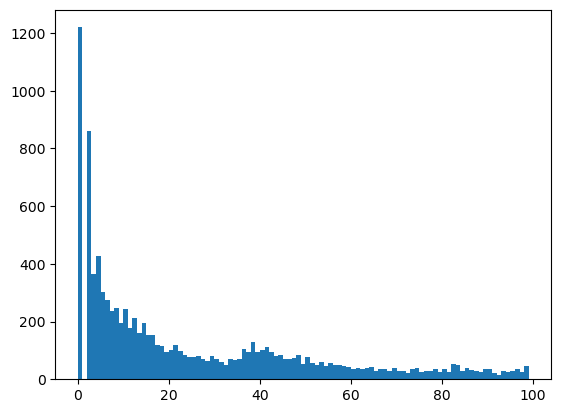

In [423]:
_ = plt.hist(all_cbg['total transcripts'], bins=np.arange(100))

In [397]:
all_cbg_clean

cre_id,CRE001,CRE002,CRE003,CRE004,CRE005,CRE006,CRE007,CRE008,CRE009,CRE010,...,CRE013,CRE014,CRE015,CRE016,CRE017,CRE018,CRE019,CRE020,total transcripts,fov
masks,,,,,,,,,,,,,,,,,,,,,
1,0,1,0,0,32,1,0,1,1,0,...,3,0,0,0,1,0,0,4,45,"[0, 1000)"
10,7,9,7,3,104,3,2,5,1,3,...,5,0,2,0,7,2,1,4,170,"[0, 1000)"
11,1,0,2,1,59,1,1,3,0,0,...,1,0,0,0,0,3,1,4,77,"[0, 1000)"
12,11,9,16,1,54,6,3,4,8,0,...,6,2,2,2,4,2,1,5,141,"[0, 1000)"
13,8,14,21,9,172,7,3,5,8,3,...,6,5,6,3,4,5,2,7,300,"[0, 1000)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224057,2,7,5,4,77,2,2,7,0,2,...,5,2,2,1,1,3,1,6,130,"[224000, 225000)"
224058,4,9,6,2,95,6,4,4,2,2,...,3,3,2,4,3,3,3,6,166,"[224000, 225000)"
224060,6,8,6,12,95,13,9,11,6,8,...,13,8,11,10,10,15,9,20,284,"[224000, 225000)"


C:\Users\zgibbs\AppData\Local\Temp\ipykernel_28588\1956980811.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sns.boxplot([all_cbg_clean.groupby('fov')[i].mean() for i in all_cbg_clean.columns[:-2]], showfliers=False)


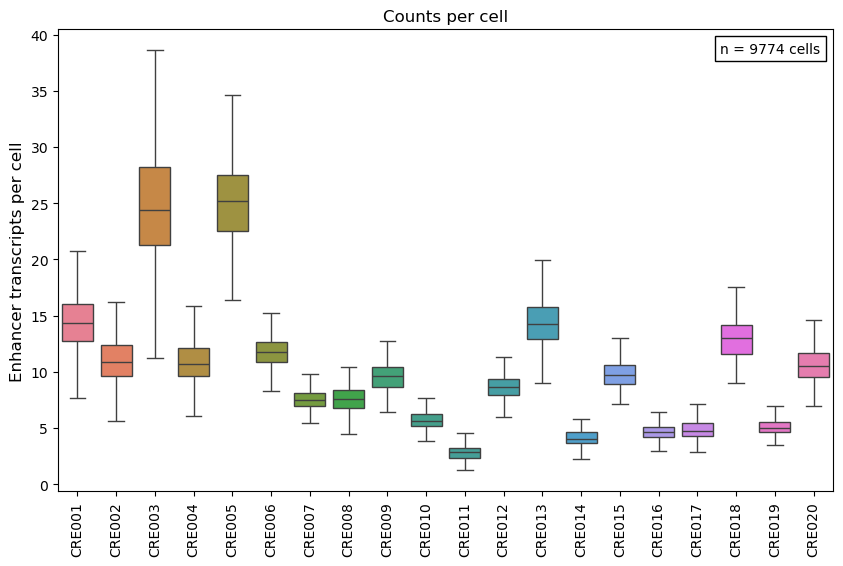

In [478]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
import seaborn as sns

fig, ax = plt.subplots(figsize=(10,6))
sns.boxplot([all_cbg_clean.groupby('fov')[i].mean() for i in all_cbg_clean.columns[:-2]], showfliers=False)
plt.xticks(np.arange(20), all_cbg_clean.columns[:20], rotation=90);
ax.set_ylabel('Enhancer transcripts per cell', fontsize=12)
ax.set_title('Counts per cell')

numcells = len(all_cbg_clean)

anchored_text = AnchoredText(f"n = {numcells} cells", loc=1)
ax.add_artist(anchored_text)

# plt.savefig('/projects/ps-renlab2/zgibbs/STARR-FISH/10_12_2023__CRE-20_RNASEQ/figures/normalized_mean_CRE_counts_per_FOV_boxplot_231227.png', dpi=600)
plt.show()

In [367]:
all_cbg_clean['total transcripts'].quantile(.1)

41.0

In [195]:
colors = {'CRE001' : '#f77189',
        'CRE002' : '#f7755d',
        'CRE003' : '#e68332',
        'CRE004' : '#ce9032',
        'CRE005' : '#bb9832',
        'CRE006' : '#aa9e31',
        'CRE007' : '#97a431',
        'CRE008' : '#7eaa31',
        'CRE009' : '#50b131',
        'CRE010' : '#32b166',
        'CRE011' : '#34af84',
        'CRE012' : '#35ae96',
        'CRE013' : '#36ada4',
        'CRE014' : '#37abb1',
        'CRE015' : '#38aabf',
        'CRE016' : '#39a7d0',
        'CRE017' : '#3ba3ec',
        'CRE018' : '#7a98f4',
        'CRE019' : '#a48cf4',
        'CRE020' : '#c67df4',
        'blank1' : '#e866f4',
        'blank2' : '#f561dd',
        'blank3' : '#f668c2',
        'blank4' : '#f66ca8'}

In [196]:
CREs = ['CRE001', 'CRE002', 'CRE003', 'CRE004', 'CRE005', 'CRE006', 'CRE007', 'CRE008',
        'CRE009', 'CRE010', 'CRE011', 'CRE012', 'CRE013', 'CRE014', 'CRE015', 'CRE016',
        'CRE017', 'CRE018', 'CRE019', 'CRE020']